# 02 — Feature Engineering

**Objective:** Derive six behavioural ratios that capture spending
patterns, repayment discipline, and cash-advance reliance. These
engineered features will feed directly into the clustering model.

**Input:** `data/processed/cleaned_customers.csv`  
**Output:** `data/processed/featured_customers.csv`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import ensure_directories, CLEANED_CSV_PATH
ensure_directories()

## 1. Load Cleaned Data

In [2]:
import pandas as pd

df = pd.read_csv(CLEANED_CSV_PATH, index_col="CUST_ID")
print(f"Loaded cleaned data: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded cleaned data: 8949 rows, 17 columns


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_66120\3679905650.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


## 2. Engineer Derived Features

| # | Feature | Formula | Rationale |
|---|---------|---------|----------|
| 1 | `UTILIZATION_RATIO` | BALANCE / CREDIT_LIMIT | Credit utilisation — key risk indicator |
| 2 | `PAYMENT_TO_BALANCE` | PAYMENTS / (BALANCE + 1) | Repayment discipline |
| 3 | `SPEND_VELOCITY` | PURCHASES / CREDIT_LIMIT | Spending aggression |
| 4 | `INSTALLMENT_FREQUENCY` | INSTALLMENTS_PURCHASES / (PURCHASES + 1) | Proportion of instalment buying |
| 5 | `CASH_ADVANCE_RATIO` | CASH_ADVANCE / (PURCHASES + CASH_ADVANCE + 1) | Cash dependence (fraud proxy) |
| 6 | `PURCHASE_TYPE_RATIO` | ONEOFF_PURCHASES / (PURCHASES + 1) | Lump-sum vs frequent buying pattern |

Each ratio uses `+1` denominator offsets or `np.clip` to handle
division-by-zero edge cases safely.

In [3]:
from src.features import engineer_features

df = engineer_features(df)
df.head()

  ✓ Engineered → UTILIZATION_RATIO (balance / credit_limit)
  ✓ Engineered → PAYMENT_TO_BALANCE (payments / (balance + 1))
  ✓ Engineered → SPEND_VELOCITY (purchases / credit_limit)
  ✓ Engineered → INSTALLMENT_FREQUENCY (installment_purchases / (purchases + 1))
  ✓ Engineered → CASH_ADVANCE_RATIO (cash_advance / (purchases + cash_advance + 1))
  ✓ Engineered → PURCHASE_TYPE_RATIO (oneoff_purchases / (purchases + 1))
  ✓ Feature engineering complete — 23 total columns


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZATION_RATIO,PAYMENT_TO_BALANCE,SPEND_VELOCITY,INSTALLMENT_FREQUENCY,CASH_ADVANCE_RATIO,PURCHASE_TYPE_RATIO
CUST_ID,,,,,,,,,,,,,,,,,,,,,
C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,...,201.802084,139.509787,0.000000,12.0,0.040901,4.816193,0.095400,0.989627,0.000000,0.000000
C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,...,4103.032597,1072.340217,0.222222,12.0,0.457495,1.280810,0.000000,0.000000,0.999845,0.000000
C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,...,622.066742,627.284787,0.000000,12.0,0.332687,0.249211,0.103089,0.000000,0.000000,0.998708
C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,...,0.000000,312.343947,0.000000,12.0,0.222223,0.000000,0.199867,0.000000,0.120641,0.999333
C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,...,678.334763,244.791237,0.000000,12.0,0.681429,0.828537,0.013333,0.000000,0.000000,0.941176


## 3. Quick Validation

Verify that all six new columns are present, contain no nulls,
and have sensible value ranges.

In [4]:
from src.utils import ENGINEERED_FEATURES

for feature in ENGINEERED_FEATURES:
    assert feature in df.columns, f"Missing: {feature}"
    assert df[feature].isnull().sum() == 0, f"Nulls in: {feature}"

print("\nEngineered feature summary:")
print(df[ENGINEERED_FEATURES].describe().round(4).T)


Engineered feature summary:
                        count     mean       std  min     25%     50%     75%  \
UTILIZATION_RATIO      8949.0   0.3851    0.3488  0.0  0.0415  0.3029  0.7176   
PAYMENT_TO_BALANCE     8949.0  16.1227  205.5614  0.0  0.3293  1.4034  7.5326   
SPEND_VELOCITY         8949.0   0.2305    0.2835  0.0  0.0111  0.1173  0.3376   
INSTALLMENT_FREQUENCY  8949.0   0.4007    0.8494  0.0  0.0000  0.1852  0.9693   
CASH_ADVANCE_RATIO     8949.0   0.3787    0.4421  0.0  0.0000  0.0000  0.9504   
PURCHASE_TYPE_RATIO    8949.0   0.3772    0.4234  0.0  0.0000  0.1099  0.8714   

                              max  
UTILIZATION_RATIO          1.0000  
PAYMENT_TO_BALANCE     14229.8825  
SPEND_VELOCITY             1.0000  
INSTALLMENT_FREQUENCY     66.9500  
CASH_ADVANCE_RATIO         1.0000  
PURCHASE_TYPE_RATIO        1.7984  


## 4. Pair Plot — Engineered Features by TENURE Quartile

This pair plot helps visualise relationships between the six
derived features and whether customer tenure influences
behavioural patterns.

In [5]:
from src.features import plot_engineered_pairplot

plot_engineered_pairplot(df)

  ✓ Engineered pairplot saved → 05_engineered_pairplot.png


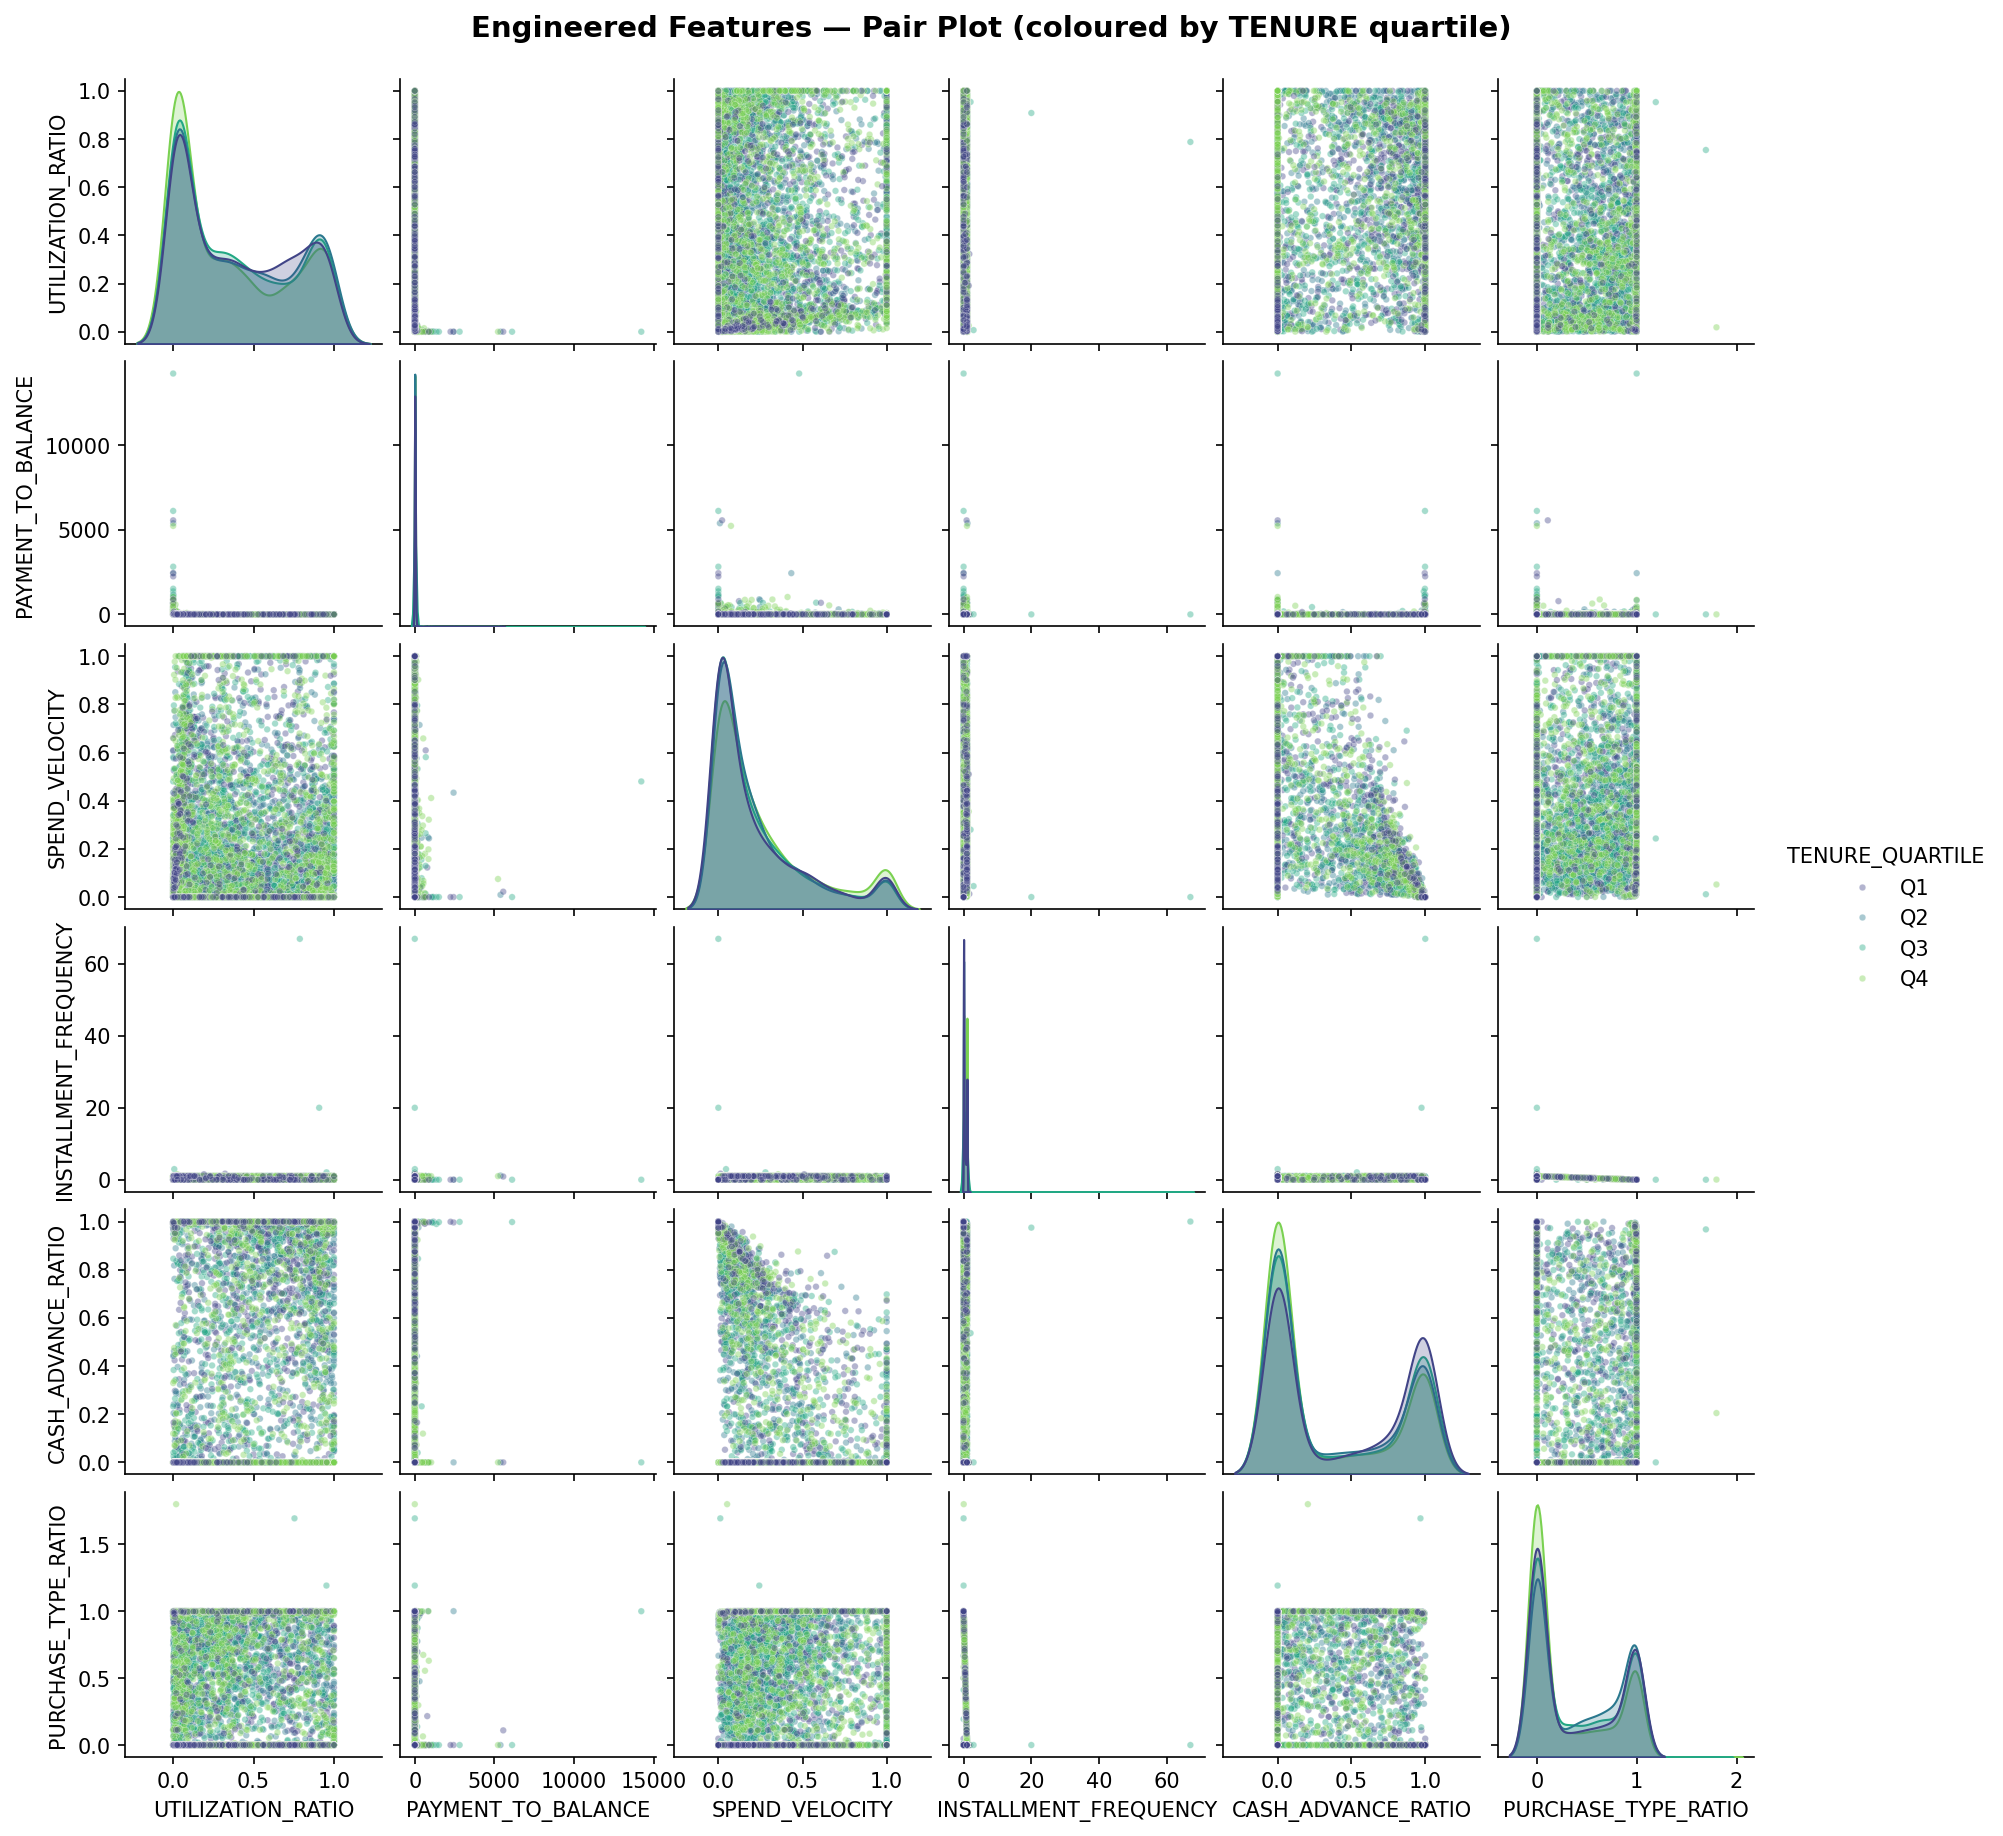

In [6]:
from IPython.display import Image
from src.utils import PLOTS_DIR

Image(filename=str(PLOTS_DIR / "05_engineered_pairplot.png"), width=900)

## 5. Save Feature-Enriched Data

In [7]:
from src.features import save_featured_data

save_featured_data(df)

  ✓ Featured data saved → data\processed\featured_customers.csv


## 6. Key Observations

- **UTILIZATION_RATIO** clusters around two modes: near-zero (dormant
  or transactor accounts) and 0.8–1.0 (revolvers near their limit).
- **CASH_ADVANCE_RATIO** is bimodal — most customers have zero cash
  advance usage, but a small cohort depends on it heavily.
- **PAYMENT_TO_BALANCE** has a long right tail, indicating a minority
  of customers who overpay relative to their balances.
- Tenure does not appear to strongly separate the engineered features,
  suggesting behaviour is more segment-driven than tenure-driven.

---
*Next: [03_Clustering_and_PCA.ipynb](03_Clustering_and_PCA.ipynb) →
normalise features, run K-Means, and visualise with PCA.*